In [36]:
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.dates as mdates

In [4]:
df_bitcon_price = pd.read_csv("data/bitcoin_price.csv")
df_bitcon_price

,DATE,CLOSE,VOLUME
0,2014-01-01,532.38,2299608.71
1,2014-01-02,545.12,1543041.85
2,2014-01-03,480.71,2346078.85
3,2014-01-04,522.66,2698832.73
4,2014-01-05,497.74,2354682.31
...,...,...,...
2199,2020-01-09,90668.56,1928143.74
2200,2020-01-10,89645.68,5449552.60
2201,2020-01-11,90798.01,3244935.86
2202,2020-01-12,98195.20,2684321.26


In [5]:
df_bitcon_price.shape

(2204, 3)

In [6]:
df_bitcon_price.dtypes

DATE          str
CLOSE     float64
VOLUME    float64
dtype: object

In [7]:
df_bitcon_search = pd.read_csv("data/bitcoin_search.csv")
df_bitcon_search

,MONTH,BTC_NEWS_SEARCH
0,2011-01,17
1,2011-02,20
2,2011-03,21
3,2011-04,22
4,2011-05,22
...,...,...
115,2020-08,13
116,2020-09,3
117,2020-10,8
118,2020-11,0


In [8]:
df_bitcon_search.dtypes

MONTH                str
BTC_NEWS_SEARCH    int64
dtype: object

In [9]:
df_tesla = pd.read_csv("data/tesla.csv")
df_tesla

,MONTH,TSLA_WEB_SEARCH,TSLA_USD_CLOSE
0,2010-01,6,12.00
1,2010-02,7,25.37
2,2010-03,10,21.05
3,2010-04,8,41.81
4,2010-05,7,33.24
...,...,...,...
119,2019-12,31,241.90
120,2020-01,33,221.24
121,2020-02,31,222.42
122,2020-03,32,222.28


In [11]:
df_tesla.isna().values.any()

np.False_

In [12]:
df_unemployment = pd.read_csv("data/unemployment.csv")
df_unemployment

,MONTH,UE_BENEFITS_WEB_SEARCH,UNRATE
0,2004-01,26,4.3
1,2004-02,21,4.2
2,2004-03,33,4.8
3,2004-04,40,4.8
4,2004-05,23,4.4
...,...,...,...
176,2018-09,35,3.6
177,2018-10,26,3.9
178,2018-11,26,4.1
179,2018-12,34,3.8


In [13]:
print(f"Missing values for Tesla?: {df_tesla.isna().values.any()}")
print(f"Missing values for U/E?: {df_unemployment.isna().values.any()}")
print(f"Missing values for BTC Search?: {df_bitcon_search.isna().values.any()}")
print(f"Missing values for BTC Price?: {df_bitcon_price.isna().values.any()}")

Missing values for Tesla?: False
Missing values for U/E?: False
Missing values for BTC Search?: False
Missing values for BTC Price?: False


In [15]:
df_bitcon_price.isna().sum()

DATE      0
CLOSE     0
VOLUME    0
dtype: int64

In [16]:
df_bitcon_price.isna().sum().sum()

np.int64(0)

In [17]:
df_bitcon_price[df_bitcon_price.isna().any(axis=1)]

,DATE,CLOSE,VOLUME


In [18]:
df_bitcon_price.dropna(inplace=True)

In [19]:
df_tesla.dtypes

MONTH                  str
TSLA_WEB_SEARCH      int64
TSLA_USD_CLOSE     float64
dtype: object

In [20]:
df_tesla.MONTH = pd.to_datetime(df_tesla.MONTH)

In [21]:
df_unemployment.MONTH = pd.to_datetime(df_unemployment.MONTH)

In [22]:
df_tesla.dtypes

MONTH              datetime64[us]
TSLA_WEB_SEARCH             int64
TSLA_USD_CLOSE            float64
dtype: object

In [23]:
df_bitcon_search.MONTH = pd.to_datetime(df_bitcon_search.MONTH)

In [24]:
df_bitcon_price.dtypes

DATE          str
CLOSE     float64
VOLUME    float64
dtype: object

In [25]:
df_bitcon_price.DATE = pd.to_datetime(df_bitcon_price.DATE)

In [26]:
df_bitcon_price.dtypes

DATE      datetime64[us]
CLOSE            float64
VOLUME           float64
dtype: object

In [30]:
# resampling
df_bitcon_price_monthly = df_bitcon_price.resample("ME", on="DATE").last()
df_bitcon_price_monthly.head()

,CLOSE,VOLUME
DATE,,
2014-01-31,722.80,2541761.98
2014-02-28,904.74,2971307.28
2014-03-31,1029.92,2682917.08
2014-04-30,990.24,3164801.60
2014-05-31,1241.38,2197725.43


In [31]:
df_bitcon_price_monthly.shape

(73, 2)

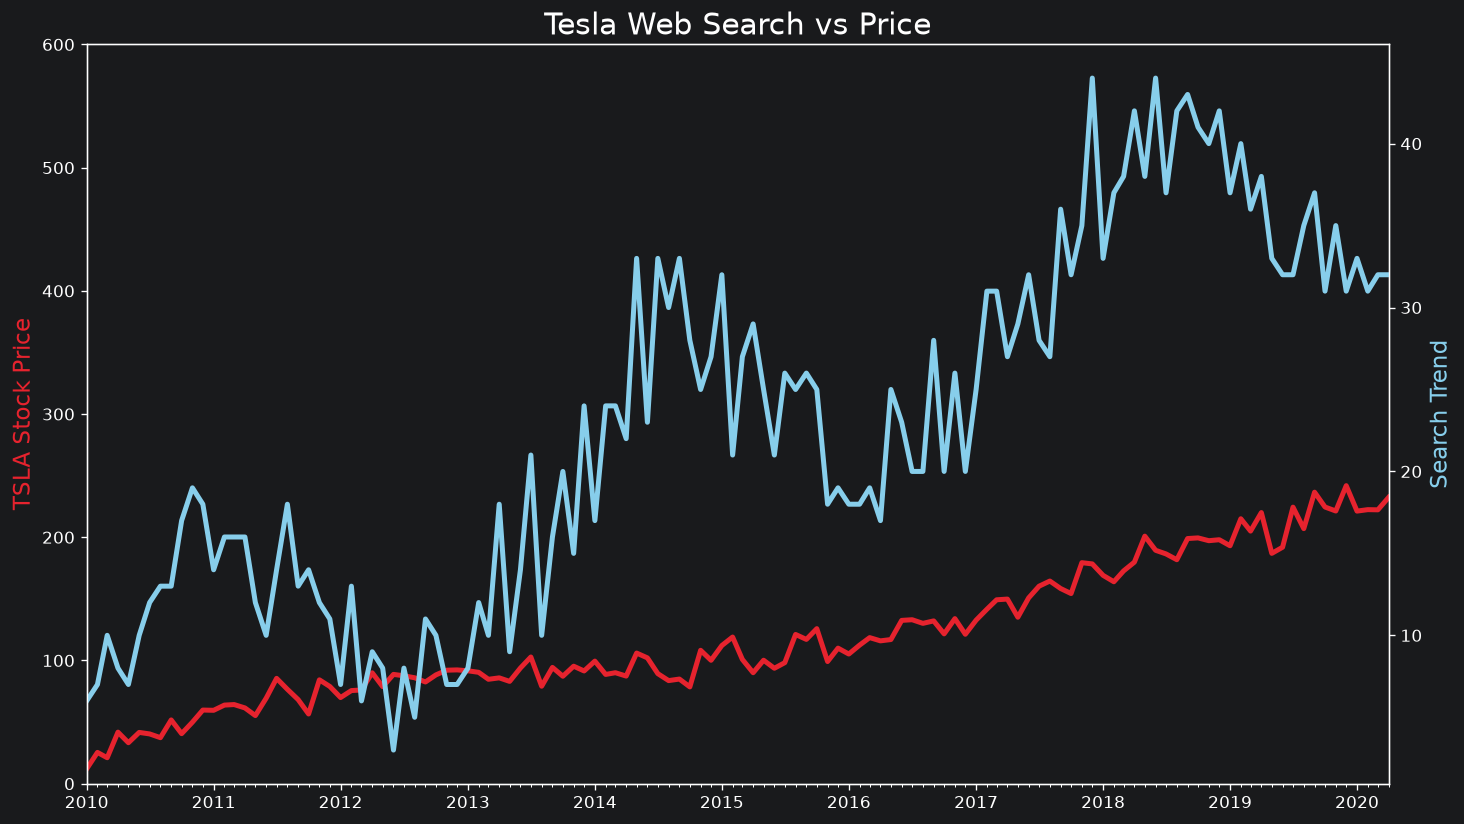

In [37]:
# tesla stock price

# increases size and resolution
plt.figure(figsize=(14,8), dpi=120)
plt.title('Tesla Web Search vs Price', fontsize=18)

ax1 = plt.gca() # get current axis
ax2 = ax1.twinx()

ax1.set_ylabel('TSLA Stock Price',color='#E6232E',fontsize=14)
ax2.set_ylabel('Search Trend',color='skyblue',fontsize=14)

# Set the minimum and maximum values on the axes
ax1.set_ylim([0, 600])
ax1.set_xlim([df_tesla.MONTH.min(), df_tesla.MONTH.max()])

ax1.plot(df_tesla.MONTH, df_tesla.TSLA_USD_CLOSE,color='#E6232E',linewidth=3)
ax2.plot(df_tesla.MONTH, df_tesla.TSLA_WEB_SEARCH,color='skyblue',linewidth=3)

# locators
years = mdates.YearLocator()
months = mdates.MonthLocator()
years_fmt = mdates.DateFormatter("%Y")

ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_major_formatter(years_fmt)
ax1.xaxis.set_minor_locator(months)

plt.show()

In [ ]:
# bitcoin

plt.figure(figsize=(14,8), dpi=120)

plt.title('Bitcoin News Search vs Resampled Price', fontsize=18)
plt.xticks(fontsize=14, rotation=45)

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.set_ylabel('BTC Price', color='#F08F2E', fontsize=14)
ax2.set_ylabel('Search Trend', color='skyblue', fontsize=14)

ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_major_formatter(years_fmt)
ax1.xaxis.set_minor_locator(months)

ax1.set_ylim(bottom=0, top=15000)
ax1.set_xlim([df_bitcon_price_monthly.index.min(), df_bitcon_price_monthly.index.max()])

# Experiment with the linestyle and markers
ax1.plot(df_bitcon_price_monthly.index, df_bitcon_price_monthly.CLOSE,
         color='#F08F2E', linewidth=3, linestyle='--')
ax2.plot(df_bitcon_price_monthly.index, df_bitcon_search.BTC_NEWS_SEARCH,
         color='skyblue', linewidth=3, marker='o')

plt.show()


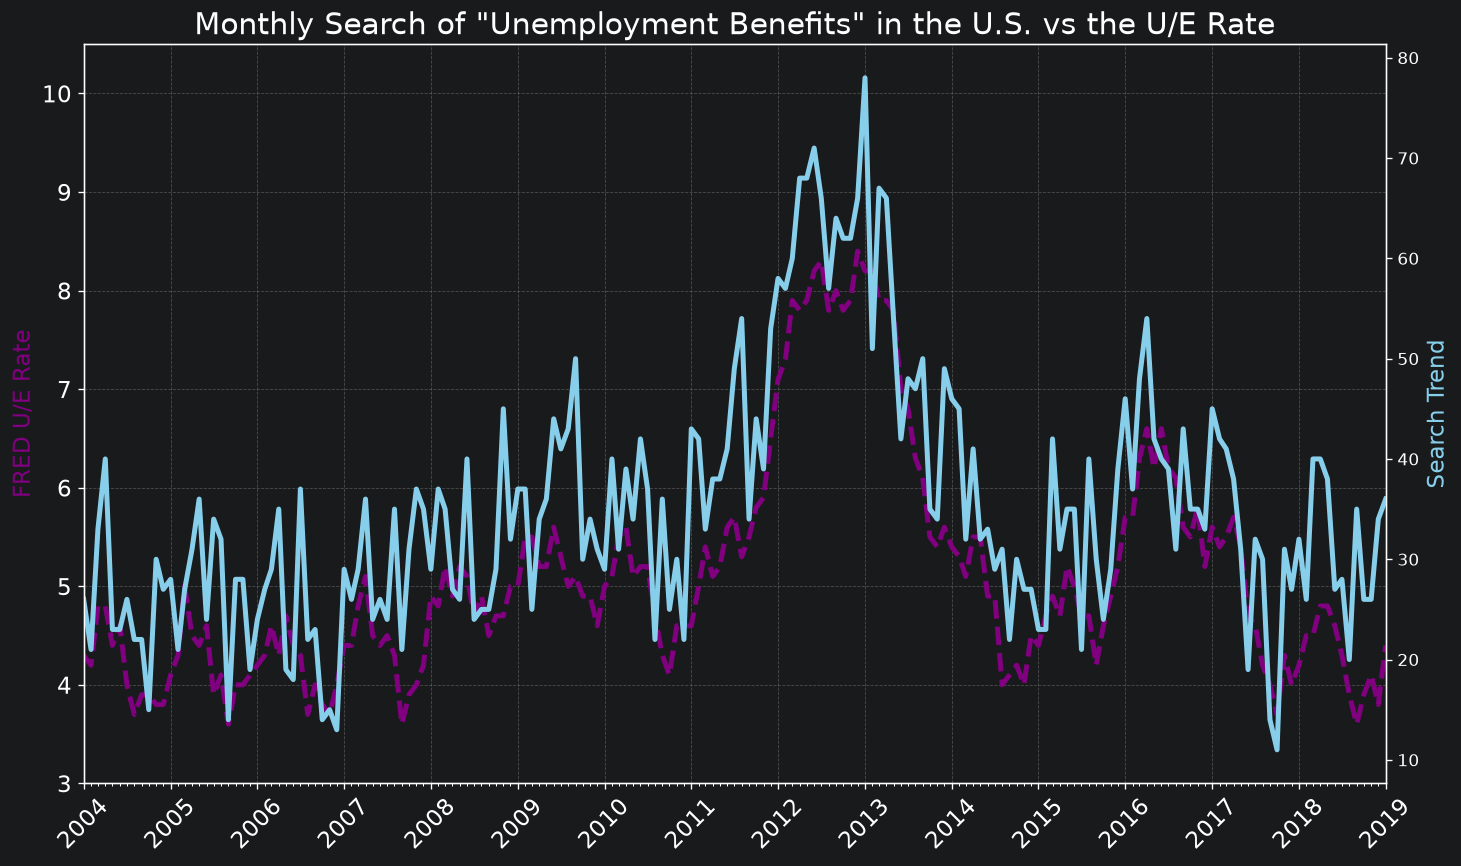

In [40]:
# unemployment
plt.figure(figsize=(14,8), dpi=120)
plt.title('Monthly Search of "Unemployment Benefits" in the U.S. vs the U/E Rate', fontsize=18)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14, rotation=45)

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.set_ylabel('FRED U/E Rate', color='purple', fontsize=14)
ax2.set_ylabel('Search Trend', color='skyblue', fontsize=14)

ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_major_formatter(years_fmt)
ax1.xaxis.set_minor_locator(months)

ax1.set_ylim(bottom=3, top=10.5)
ax1.set_xlim([df_unemployment.MONTH.min(), df_unemployment.MONTH.max()])

# Show the grid lines as dark grey lines
ax1.grid(color='grey', linestyle='--')

# Change the dataset used
ax1.plot(df_unemployment.MONTH, df_unemployment.UNRATE,
         color='purple', linewidth=3, linestyle='--')
ax2.plot(df_unemployment.MONTH, df_unemployment.UE_BENEFITS_WEB_SEARCH,
         color='skyblue', linewidth=3)

plt.show()